In [19]:
import pandas as pd 
import numpy as np
from keras.models import Model
from keras import models
from sklearn.preprocessing import StandardScaler 
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.layers import Input, Dropout, Conv2D, Dense, MaxPooling2D, Flatten
from sklearn.model_selection import train_test_split

In [20]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [21]:
X_train.shape

(60000, 28, 28)

In [22]:
X_test.shape

(10000, 28, 28)

In [23]:
y_test.shape

(10000,)

In [24]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [25]:
num_rows = 28
num_cols = 28
num_digit = 10

In [26]:
#reshaping the data
#because CNN wants (samples, height, width, channels)
X_train = X_train.reshape(X_train.shape[0], 28, 28,1)
X_train = X_train.astype("float32")/255
X_test = X_test.reshape(X_test.shape[0], 28, 28,1)
X_test = X_test.astype("float32")/255

In [27]:
X_train.shape


(60000, 28, 28, 1)

In [28]:
X_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [29]:
X_test.shape

(10000, 28, 28, 1)

In [30]:
#One-Hot Encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [31]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [32]:
model = models.Sequential()
model.add(Conv2D(64, kernel_size=(3,3),activation = "relu",input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, kernel_size=(3,3),activation = "relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128,activation = "relu"))
model.add(Dense(10,activation = "softmax"))

In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,922 (480.16 KB)

 Trainable params: 122,922 (480.16 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    loss = "categorical_crossentropy",
    optimizer = "SGD",
    metrics = ["accuracy"]
)

In [35]:
sushant = model.fit(
    X_train,y_train,
    epochs = 10,
    validation_data = (X_test,y_test),
    verbose = 1,
    batch_size = 128,
    
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.6165 - loss: 1.4140 - val_accuracy: 0.8524 - val_loss: 0.4769
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.8942 - loss: 0.3538 - val_accuracy: 0.9226 - val_loss: 0.2602
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9264 - loss: 0.2487 - val_accuracy: 0.9391 - val_loss: 0.2079
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9418 - loss: 0.1963 - val_accuracy: 0.9530 - val_loss: 0.1621
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9517 - loss: 0.1623 - val_accuracy: 0.9562 - val_loss: 0.1439
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9588 - loss: 0.1384 - val_accuracy: 0.9639 - val_loss: 0.1190
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9635 - loss: 0.1218 - val_accuracy: 0.9693 - val_loss: 0.1016
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9673 - loss: 0.1095 - 

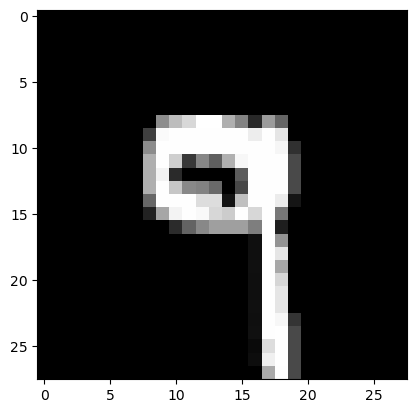

Actual Label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [65]:
import matplotlib.pyplot as plt

index = 6000   # choose any index

plt.imshow(X_test[index].reshape(28,28), cmap="gray")
plt.show()

print("Actual Label:", y_test[index])

In [66]:
sample = X_test[index].reshape(1, 28, 28, 1)

prediction = model.predict(sample)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[5.8780092e-08 2.4705324e-07 4.9615296e-06 1.8981136e-04 1.4521718e-03
  2.3574075e-05 1.6807011e-09 7.4671349e-04 3.2050000e-04 9.9726200e-01]]


In [67]:
predicted_digit = np.argmax(prediction)
print("predicted didgit = ",predicted_digit)

predicted didgit =  9
